# LAB-D1-01 SOLUTION: One-Neuron Boundary Workshop

**INSTRUCTOR ONLY - DO NOT DISTRIBUTE WITH PARTICIPANT MATERIALS**

**Canonical objectives:** `OBJ-D1-01`, `OBJ-D1-02`, `OBJ-D1-03`  
**Reference environment:** local CPU; Python 3.11+; no network, download, or GPU  
**Expected compute runtime:** under 10 seconds (reference validation records wall time separately)  
**Execution contract:** Restart Kernel -> Run All; this notebook is standalone.

This solution preserves the participant sequence and completes every prediction, implementation,
diagnosis, reflection, deliberate failure, and practical extension. Labeled instructor answers sit
beside the corresponding prompts. Stored outputs are reference evidence from the clean validation run,
not promises that every supported environment will render identical timings or pixels.


In [1]:
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

SEED = 11
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.figsize": (7, 5), "axes.grid": True, "grid.alpha": 0.22})

print(f"Python {platform.python_version()} | NumPy {np.__version__} | matplotlib {matplotlib.__version__}")
print("Runtime target: CPU; no network access required.")

Python 3.11.8 | NumPy 2.4.6 | matplotlib 3.11.1
Runtime target: CPU; no network access required.


## Recap and Starter State

A neuron first computes the weighted score $z = w \cdot x + b$. A sigmoid can transform that score into a number between 0 and 1, and a threshold converts the number into a class prediction.

The boundary for threshold 0.5 is the set of points where $z=0$. The weight vector controls orientation and the bias changes location. Distance and parameter scale also affect probability confidence.

The starter data contains 12 fixed labeled points, a seeded 40-point linearly separable extension, and six unlabeled probes. The data and plot scaffolding are supplied; your implementation is limited to the neuron's core operations and manual parameter choice.

In [2]:
X_fixed = np.array([
    [-2.0, -1.0], [-1.7, 0.2], [-1.2, -0.2], [-0.8, 0.1],
    [-0.5, 0.6], [-0.2, -0.8], [0.2, 0.1], [0.5, -0.4],
    [0.8, 0.0], [1.1, -0.8], [1.5, 0.2], [2.0, -0.6],
], dtype=float)
y_fixed = np.array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1], dtype=int)

extension_0 = rng.normal(loc=(-1.1, -0.8), scale=(0.32, 0.30), size=(20, 2))
extension_1 = rng.normal(loc=(1.1, 0.8), scale=(0.32, 0.30), size=(20, 2))
X_extension = np.vstack([extension_0, extension_1])
y_extension = np.repeat([0, 1], 20)

probe_names = np.array(["west", "northwest", "center", "southeast", "east", "far-east"])
X_probes = np.array([[-1.6, -0.4], [-0.6, 0.8], [0.0, 0.0], [0.8, -0.5], [1.2, 0.4], [2.2, -0.2]])

assert X_fixed.shape == (12, 2)
assert X_extension.shape == (40, 2)
assert X_probes.shape == (6, 2)
print("Dataset ready: 12 fixed points, 40 extension points, and 6 unlabeled probes.")

Dataset ready: 12 fixed points, 40 extension points, and 6 unlabeled probes.


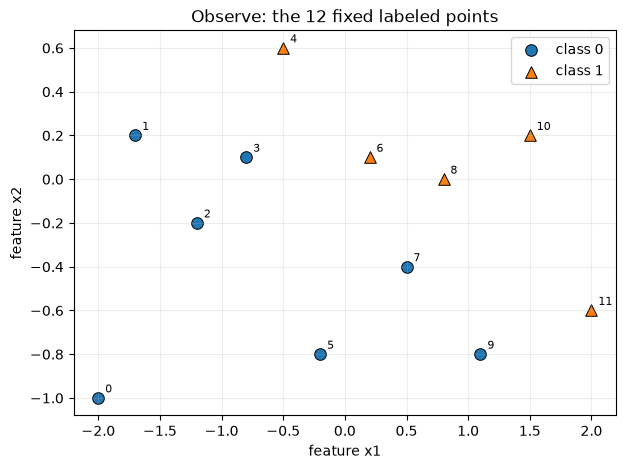

In [3]:
def plot_labeled_points(X, y, title, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    for label, marker, name in [(0, "o", "class 0"), (1, "^", "class 1")]:
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], marker=marker, s=70, edgecolor="black", linewidth=0.7, label=name)
    for index, point in enumerate(X):
        ax.annotate(str(index), point, xytext=(5, 4), textcoords="offset points", fontsize=8)
    ax.set(xlabel="feature x1", ylabel="feature x2", title=title)
    ax.legend()
    return ax

plot_labeled_points(X_fixed, y_fixed, "Observe: the 12 fixed labeled points")
plt.show()

## Predict: Commit Before the Reveal

Without running a neuron yet, write a prediction for each isolated change:

1. Increase only `w1`. What should happen to boundary orientation?
2. Increase only `w2`. What should happen to boundary orientation?
3. Increase only `b`. Should the boundary rotate, translate, or both?
4. Multiply `w1`, `w2`, and `b` by the same positive number. What should happen to the 0.5 contour and to probability confidence away from it?
5. Circle two numbered fixed points that you expect to be hardest for an initial straight boundary.

Do not infer that sharper sigmoid confidence means better probability calibration. This visual studies geometry, not calibration.

In [4]:
prediction_log = {
    "increase_w1": "The weight ratio changes, so the line generally rotates; the exact direction depends on both weights.",
    "increase_w2": "The weight ratio changes, so the line generally rotates; w2 is not a pure rotation knob.",
    "increase_bias": "With weights fixed, the line translates parallel to itself and does not rotate.",
    "scale_all_parameters": "The z=0 / p=0.5 contour is unchanged, while off-boundary sigmoid values move farther from 0.5.",
    "two_hard_point_indices": "Points 4 and 7 are plausible hard cases because they oppose the broad left/right pattern near the initial line.",
}
assert all(value.strip() for value in prediction_log.values())
print("Completed instructor prediction record:")
for key, value in prediction_log.items():
    print(f"- {key}: {value}")


Completed instructor prediction record:
- increase_w1: The weight ratio changes, so the line generally rotates; the exact direction depends on both weights.
- increase_w2: The weight ratio changes, so the line generally rotates; w2 is not a pure rotation knob.
- increase_bias: With weights fixed, the line translates parallel to itself and does not rotate.
- scale_all_parameters: The z=0 / p=0.5 contour is unchanged, while off-boundary sigmoid values move farther from 0.5.
- two_hard_point_indices: Points 4 and 7 are plausible hard cases because they oppose the broad left/right pattern near the initial line.


### Instructor Answer and Hint Ladder

**Answer:** Bias-only motion is a parallel translation. Either individual weight changes the normal
vector ratio and generally rotates the boundary. Positive common scaling preserves the zero contour
and class signs while making off-boundary sigmoid outputs more extreme.

**Hint ladder before reveal:** (1) Set `p=0.5`. (2) Convert that to `z=0`. (3) Ask what stays fixed in
`w1*x1 + w2*x2 + b = 0`. (4) Factor a common positive scale from the equation.

**Common wrong answer:** "w1 rotates and w2 translates." Neither weight has a universal one-motion
meaning; orientation depends on the full weight vector.


## Modify: Implement One Neuron

Complete only the marked `TODO` bodies.

- `weighted_sum`: accept a batch shaped `(n_examples, 2)` and return `(n_examples,)`.
- `sigmoid`: preserve the input shape and avoid overflow for large magnitudes.
- `probability_to_class`: apply the supplied threshold and return integer classes.
- `boundary_coefficients`: validate two weights and return coefficients in a form the contour helper can use without dividing by a weight.

Each placeholder raises `NotImplementedError` only when you call it. The setup cells above remain runnable in the starter notebook.

In [5]:
def weighted_sum(X, weights, bias):
    # Return one weighted score per example.
    X = np.asarray(X, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if X.ndim != 2 or weights.shape != (X.shape[1],):
        raise ValueError(f"Expected X (n, d) and weights (d,); got {X.shape} and {weights.shape}")
    return X @ weights + float(bias)


def sigmoid(scores):
    # Return numerically stable sigmoid probabilities.
    scores = np.asarray(scores, dtype=float)
    result = np.empty_like(scores)
    nonnegative = scores >= 0
    result[nonnegative] = 1.0 / (1.0 + np.exp(-scores[nonnegative]))
    exp_scores = np.exp(scores[~nonnegative])
    result[~nonnegative] = exp_scores / (1.0 + exp_scores)
    return result


def probability_to_class(probabilities, threshold=0.5):
    # Return integer class predictions using the threshold.
    return (np.asarray(probabilities) >= float(threshold)).astype(int)


def boundary_coefficients(weights, bias):
    # Return validated coefficients for w1*x1 + w2*x2 + b = 0.
    weights = np.asarray(weights, dtype=float)
    bias = float(bias)
    if weights.shape != (2,) or not np.all(np.isfinite(weights)) or not np.isfinite(bias):
        raise ValueError("Boundary requires exactly two finite weights and one finite bias.")
    if np.allclose(weights, 0.0):
        raise ValueError("At least one boundary weight must be nonzero.")
    return weights.copy(), bias


### Instructor Implementation Rationale

The stable sigmoid branches by score sign, so it never evaluates the overflowing exponential form.
Returning affine coefficients instead of slope/intercept is what makes vertical and near-vertical
boundaries ordinary cases. Equivalent valid implementations include `np.clip` before exponentiation
or a library expit function, but this NumPy-only branch makes the numerical mechanism visible.


## Run: Six Probe Examples

After completing the functions, run the next cell. It reveals scores, probabilities, and predicted classes for six probes. Check shape and range before interpreting individual values.

In [6]:
initial_weights = np.array([0.4, 0.3])
initial_bias = -0.1

probe_scores = weighted_sum(X_probes, initial_weights, initial_bias)
probe_probabilities = sigmoid(probe_scores)
probe_predictions = probability_to_class(probe_probabilities)

assert probe_scores.shape == (6,)
assert probe_probabilities.shape == (6,)
assert np.all((0.0 <= probe_probabilities) & (probe_probabilities <= 1.0))
assert probe_predictions.shape == (6,)

print(f"{'probe':<12} {'z':>8} {'probability':>13} {'class':>7}")
for name, score, probability, prediction in zip(probe_names, probe_scores, probe_probabilities, probe_predictions):
    print(f"{name:<12} {score:>8.3f} {probability:>13.3f} {prediction:>7d}")

probe               z   probability   class
west           -0.860         0.297       0
northwest      -0.100         0.475       0
center         -0.100         0.475       0
southeast       0.070         0.517       1
east            0.500         0.622       1
far-east        0.720         0.673       1


## Visualize: Probability Shading and the 0.5 Contour

The plot exposes one relationship: how a straight score boundary relates to sigmoid probabilities and class predictions. Observe whether the 0.5 contour passes where $w \cdot x + b=0$ and which points lie near it.

Do **not** infer that the shading is a calibrated real-world probability. These parameters were chosen for geometry, not learned from representative data.

In [7]:
def evaluate_neuron(X, weights, bias):
    scores = weighted_sum(X, weights, bias)
    probabilities = sigmoid(scores)
    predictions = probability_to_class(probabilities)
    return scores, probabilities, predictions


def decision_mesh(X, padding=0.6, resolution=180):
    x1 = np.linspace(X[:, 0].min() - padding, X[:, 0].max() + padding, resolution)
    x2 = np.linspace(X[:, 1].min() - padding, X[:, 1].max() + padding, resolution)
    xx1, xx2 = np.meshgrid(x1, x2)
    return xx1, xx2, np.column_stack([xx1.ravel(), xx2.ravel()])


def plot_neuron(X, y, weights, bias, title, ax=None, reference=None, annotate=False):
    if ax is None:
        _, ax = plt.subplots()
    checked_weights, checked_bias = boundary_coefficients(weights, bias)
    xx1, xx2, grid = decision_mesh(X)
    grid_scores = weighted_sum(grid, checked_weights, checked_bias).reshape(xx1.shape)
    grid_probabilities = sigmoid(grid_scores)
    shading = ax.contourf(xx1, xx2, grid_probabilities, levels=np.linspace(0, 1, 9), cmap="cividis", alpha=0.42)
    ax.contour(xx1, xx2, grid_scores, levels=[0.0], colors=["black"], linewidths=2)
    if reference is not None:
        reference_weights, reference_bias = reference
        reference_scores = weighted_sum(grid, reference_weights, reference_bias).reshape(xx1.shape)
        ax.contour(xx1, xx2, reference_scores, levels=[0.0], colors=["black"], linestyles="--", linewidths=1.4)
    plot_labeled_points(X, y, title, ax=ax)
    if annotate:
        for index, point in enumerate(X):
            ax.annotate(str(index), point, xytext=(5, 4), textcoords="offset points", fontsize=8)
    ax.text(0.02, 0.02, "solid: current 0.5 contour\ndashed: reference", transform=ax.transAxes, fontsize=8, va="bottom")
    return shading


def accuracy_for(X, y, weights, bias):
    return np.mean(evaluate_neuron(X, weights, bias)[2] == y)

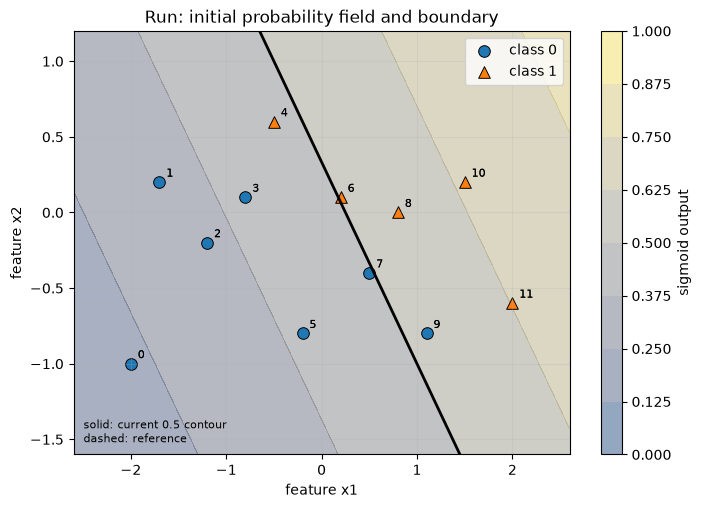

Initial fixed-point accuracy: 0.833 (10/12)
Indices currently misclassified: [4, 9]


In [8]:
initial_scores, initial_probabilities, initial_predictions = evaluate_neuron(X_fixed, initial_weights, initial_bias)
initial_accuracy = np.mean(initial_predictions == y_fixed)
initial_misses = np.flatnonzero(initial_predictions != y_fixed)

fig, ax = plt.subplots(figsize=(8, 5.5))
shading = plot_neuron(X_fixed, y_fixed, initial_weights, initial_bias, "Run: initial probability field and boundary", ax=ax, annotate=True)
fig.colorbar(shading, ax=ax, label="sigmoid output")
plt.show()

print(f"Initial fixed-point accuracy: {initial_accuracy:.3f} ({np.sum(initial_predictions == y_fixed)}/12)")
print("Indices currently misclassified:", initial_misses.tolist())
assert initial_scores.shape == (12,)
assert len(initial_misses) == 2, "The supplied baseline should expose two near-boundary misses."

### Instructor Reference Result

**Expected deterministic result:** `10/12 = 0.8333`, with exactly two misses.

**What happened?** A valid affine/sigmoid computation misclassified two supplied points.  
**Why?** The initial fixed line does not place every target on the required score-sign side.  
**Concept:** A wrong class can be a model/parameter result even when the implementation is correct.


## Modify: Isolate One Parameter at a Time

Choose three comparison settings. Each must change only the named quantity. Then choose one positive common scale factor. Keep the initial setting as the dashed reference in every plot.

Before entering values, state which probe you will track and which visible property should remain unchanged in each comparison.

In [9]:
w1_test_weights = np.array([0.9, initial_weights[1]])
w2_test_weights = np.array([initial_weights[0], 0.9])
bias_test_value = 0.25
scale_factor = 2.0
tracked_probe_index = 4  # east

assert w1_test_weights.shape == (2,) and w2_test_weights.shape == (2,)
assert w1_test_weights[1] == initial_weights[1] and w1_test_weights[0] != initial_weights[0]
assert w2_test_weights[0] == initial_weights[0] and w2_test_weights[1] != initial_weights[1]
assert float(bias_test_value) != initial_bias
assert float(scale_factor) > 0 and not np.isclose(float(scale_factor), 1.0)
assert 0 <= int(tracked_probe_index) < len(X_probes)


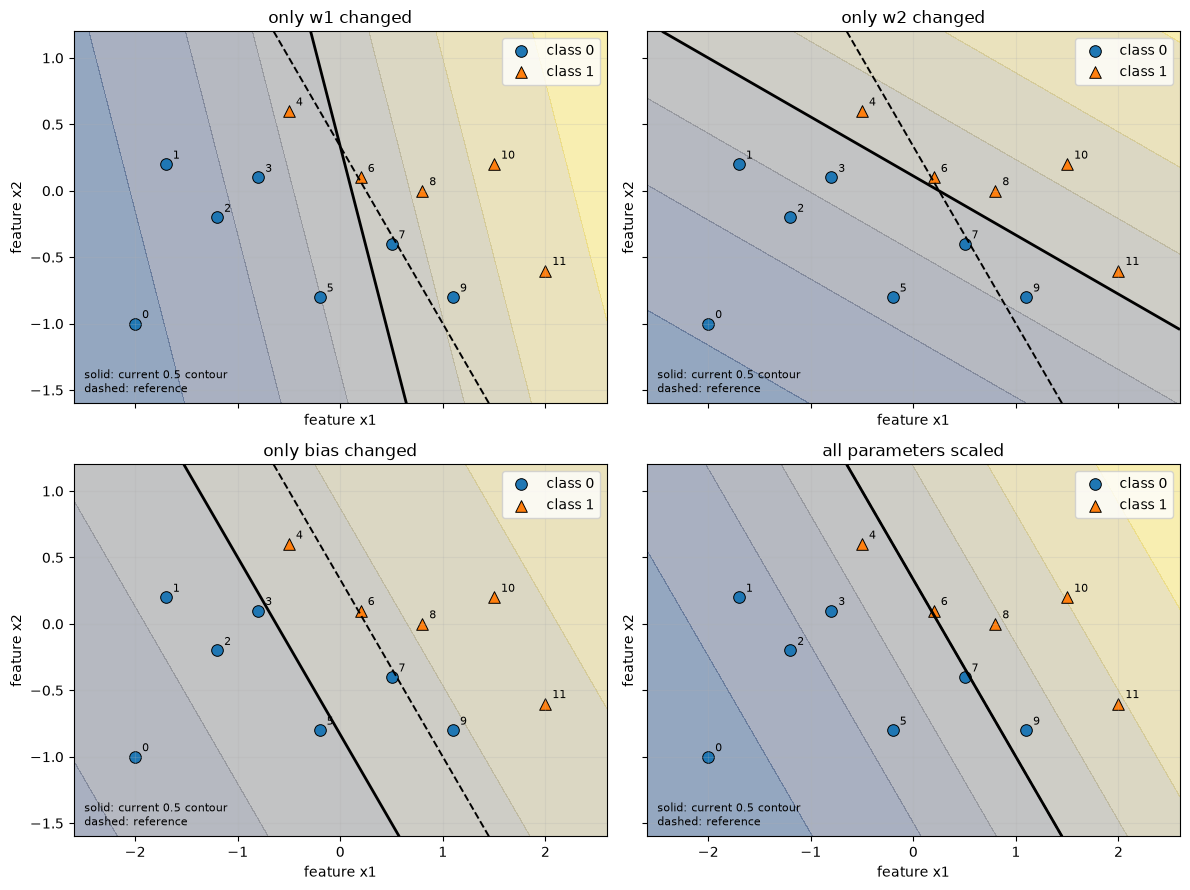

Tracked probe: east; baseline probability=0.622
only w1 changed          accuracy=0.750 tracked_probability=0.750
only w2 changed          accuracy=1.000 tracked_probability=0.677
only bias changed        accuracy=0.833 tracked_probability=0.701
all parameters scaled    accuracy=0.833 tracked_probability=0.731


In [10]:
experiment_settings = [
    ("only w1 changed", w1_test_weights, initial_bias),
    ("only w2 changed", w2_test_weights, initial_bias),
    ("only bias changed", initial_weights.copy(), float(bias_test_value)),
    ("all parameters scaled", initial_weights * float(scale_factor), initial_bias * float(scale_factor)),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
base_probe_probability = probe_probabilities[int(tracked_probe_index)]
comparison_rows = []
for ax, (label, weights, bias) in zip(axes.ravel(), experiment_settings):
    plot_neuron(X_fixed, y_fixed, weights, bias, label, ax=ax, reference=(initial_weights, initial_bias))
    probability = evaluate_neuron(X_probes[[int(tracked_probe_index)]], weights, bias)[1][0]
    comparison_rows.append((label, accuracy_for(X_fixed, y_fixed, weights, bias), probability))
plt.tight_layout()
plt.show()

print(f"Tracked probe: {probe_names[int(tracked_probe_index)]}; baseline probability={base_probe_probability:.3f}")
for label, accuracy, probability in comparison_rows:
    print(f"{label:<24} accuracy={accuracy:.3f} tracked_probability={probability:.3f}")

## Diagnose: Geometry, Confidence, and Invariants

For each panel, record: one geometric change, one numerical change, and one invariant. Reconcile any prediction that did not match the evidence. Accuracy alone is not enough: two settings can classify the same finite points while producing different boundaries or probabilities.

In [11]:
isolation_observations = {
    "only_w1": "The solid contour rotates because the normal-vector ratio changes; the east probe probability also changes.",
    "only_w2": "The solid contour rotates in a different direction; neither orientation nor the tracked probability is invariant.",
    "only_bias": "The contour translates parallel to the dashed line; its orientation is invariant while the east probability changes.",
    "common_scaling": "The solid and dashed zero contours coincide and score signs match, but the east probability moves farther from 0.5.",
}
assert all(value.strip() for value in isolation_observations.values())
for key, value in isolation_observations.items():
    print(f"{key}: {value}")


only_w1: The solid contour rotates because the normal-vector ratio changes; the east probe probability also changes.
only_w2: The solid contour rotates in a different direction; neither orientation nor the tracked probability is invariant.
only_bias: The contour translates parallel to the dashed line; its orientation is invariant while the east probability changes.
common_scaling: The solid and dashed zero contours coincide and score signs match, but the east probability moves farther from 0.5.


## Diagnose a Change-Everything Attempt

The next supplied comparison changes both weights and the bias at once. Predict whether the result will let you attribute a rotation, translation, or probability change to one parameter. Run it, then explain what additional controlled comparison would discriminate between competing explanations.

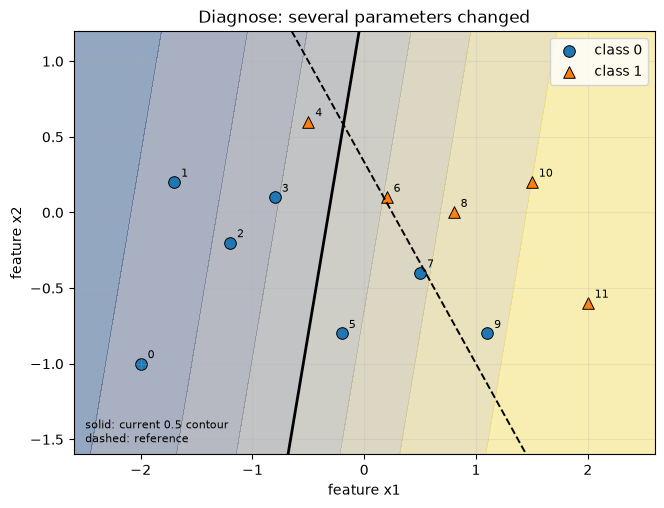

This run is evidence of a combined change; it does not isolate a single cause.


In [12]:
ambiguous_weights = initial_weights + np.array([0.7, -0.55])
ambiguous_bias = initial_bias + 0.45
fig, ax = plt.subplots(figsize=(7.5, 5.5))
plot_neuron(X_fixed, y_fixed, ambiguous_weights, ambiguous_bias, "Diagnose: several parameters changed", ax=ax, reference=(initial_weights, initial_bias))
plt.show()
print("This run is evidence of a combined change; it does not isolate a single cause.")

### Instructor Answer: Change-Everything Diagnosis

The panel shows a different boundary and probability field, but it cannot attribute the change to one
parameter because both orientation controls and location changed. Reset to the baseline and compare
one weight or the bias at a time. This is a controlled-experiment lesson, not merely a plotting lesson.


## Challenge: Manual Parameter Search

Open [ACT-D1-02 - Be the Neural Network](../challenges/day-1-challenges.md#act-d1-02---be-the-neural-network). Add at least two controlled attempts to the history below. Change one quantity between adjacent attempts when possible, and write your reason before running each attempt.

The fixed-point checkpoint accepts multiple settings. The goal is at least 10 of 12 correct, not a hidden target vector. Keep extension-set accuracy separate so a tiny fixed-set result does not masquerade as broad evidence.

In [13]:
attempt_history = [
    {"label": "supplied baseline", "weights": initial_weights.copy(), "bias": initial_bias, "reason": "baseline"},
    {"label": "increase w2", "weights": np.array([0.4, 2.0]), "bias": -0.1, "reason": "rotate toward the alternating low-x1 points"},
    {"label": "then increase w1", "weights": np.array([1.0, 2.0]), "bias": -0.1, "reason": "restore more positive x1 contribution while holding w2"},
    {"label": "then lower bias", "weights": np.array([1.0, 2.0]), "bias": -0.2, "reason": "translate the final line without changing orientation"},
]

evaluated_attempts = []
for attempt in attempt_history:
    weights = np.asarray(attempt["weights"], dtype=float)
    bias = float(attempt["bias"])
    fixed_accuracy = accuracy_for(X_fixed, y_fixed, weights, bias)
    extension_accuracy = accuracy_for(X_extension, y_extension, weights, bias)
    evaluated_attempts.append({**attempt, "weights": weights, "bias": bias, "fixed_accuracy": fixed_accuracy, "extension_accuracy": extension_accuracy})

best_attempt = max(
    enumerate(evaluated_attempts),
    key=lambda indexed_item: (indexed_item[1]["fixed_accuracy"], indexed_item[0]),
)[1]
best_weights = best_attempt["weights"].copy()
best_bias = best_attempt["bias"]
best_accuracy = best_attempt["fixed_accuracy"]
for attempt in evaluated_attempts:
    print(f"{attempt['label']:<20} fixed={attempt['fixed_accuracy']:.3f} extension={attempt['extension_accuracy']:.3f} reason={attempt['reason']}")
assert best_accuracy >= 10 / 12


supplied baseline    fixed=0.833 extension=1.000 reason=baseline
increase w2          fixed=0.917 extension=1.000 reason=rotate toward the alternating low-x1 points
then increase w1     fixed=1.000 extension=1.000 reason=restore more positive x1 contribution while holding w2
then lower bias      fixed=1.000 extension=1.000 reason=translate the final line without changing orientation


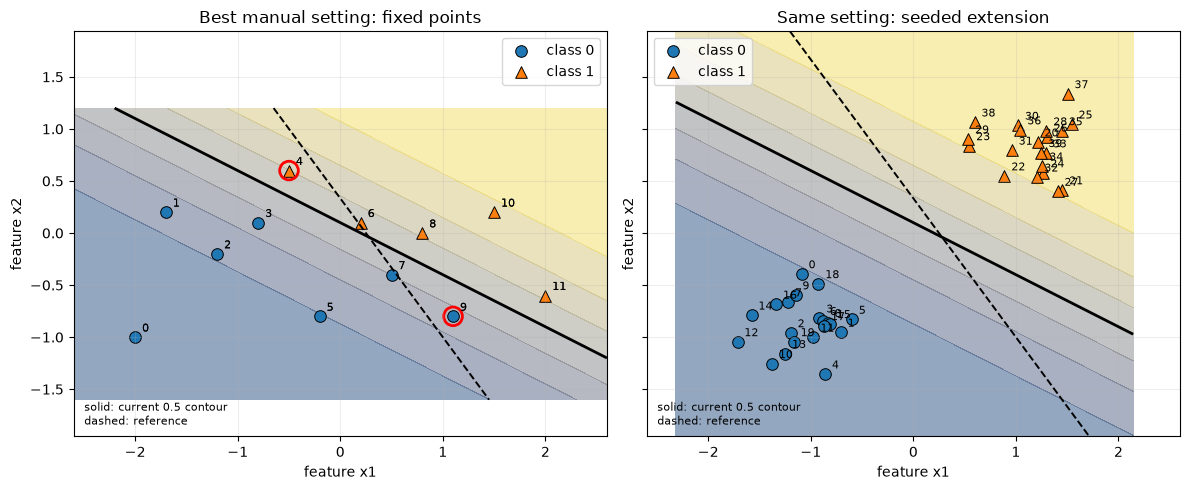

Selected attempt: then lower bias | fixed=1.000 | extension=1.000


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
plot_neuron(X_fixed, y_fixed, best_weights, best_bias, "Best manual setting: fixed points", ax=axes[0], reference=(initial_weights, initial_bias), annotate=True)
plot_neuron(X_extension, y_extension, best_weights, best_bias, "Same setting: seeded extension", ax=axes[1], reference=(initial_weights, initial_bias))
for index in initial_misses:
    axes[0].scatter(*X_fixed[index], s=180, facecolors="none", edgecolors="red", linewidths=2)
plt.tight_layout()
plt.show()
print(f"Selected attempt: {best_attempt['label']} | fixed={best_accuracy:.3f} | extension={best_attempt['extension_accuracy']:.3f}")

### Instructor Answer: Manual Search

The final controlled path reaches `weights=[1.0, 2.0]`, `bias=-0.2`; under the supplied seed it scores
`12/12` fixed and `40/40` extension examples. Many separators are acceptable: the checkpoint evaluates
score signs and evidence, not a magic vector. Manual search becomes impractical because parameter
interactions and candidate settings grow rapidly; Day 2 adds an objective and update rule.


## Diagnose the Two Baseline Misses

The red rings mark the two points missed by the supplied baseline. For each, compare score sign, distance from the contour, and target. Explain whether your manual change moved the boundary, changed orientation, changed off-boundary confidence, or combined effects. Then compare fixed-set and extension-set evidence.

### Instructor Answer: Baseline Misses

The supplied baseline computes valid finite scores for both missed points, but their score signs place
them on the wrong side of the `0.5` contour for their targets. The controlled manual sequence changes
orientation first and location last, moving those points across the decision boundary.

**What happened?** Two complete predictions disagreed with their targets.  
**Why?** The initial fixed weights and bias positioned a valid line poorly for those exceptions.  
**Concept:** Model/parameter errors differ from implementation failures; fixed-set improvement should
still be checked against separate extension evidence.


## Break/Fix Check: A Vertical Boundary

Predict what happens if the second weight is exactly zero. A slope-intercept implementation would divide by that weight. The supplied visual instead contours the score grid, so the same strategy must handle vertical and near-vertical boundaries.

### Instructor Answer Before Running

With `w2=0`, the boundary is `x1=0.25`. Slope-intercept code that divides by `w2` fails, but contouring
the affine score at zero works unchanged. A near-zero `w2` should also render without a numerical cliff.


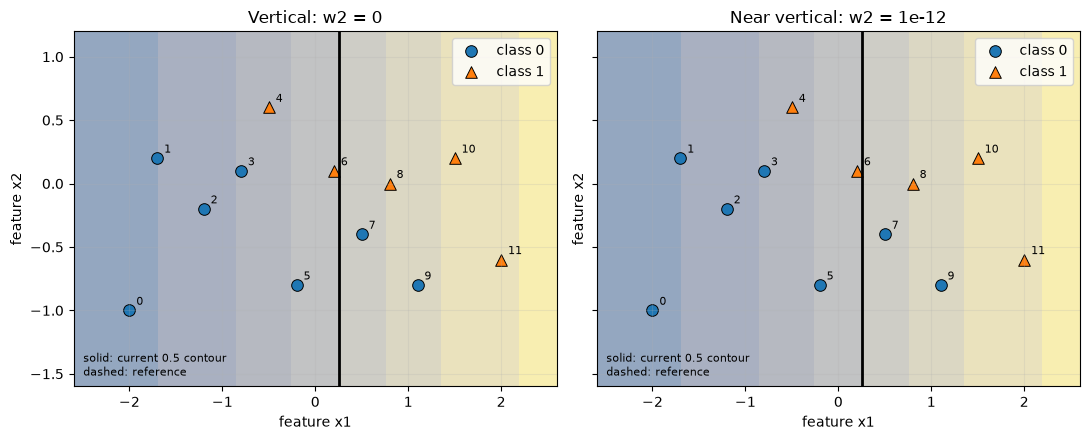

In [15]:
vertical_weights = np.array([1.0, 0.0])
vertical_bias = -0.25
near_vertical_weights = np.array([1.0, 1e-12])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
plot_neuron(X_fixed, y_fixed, vertical_weights, vertical_bias, "Vertical: w2 = 0", ax=axes[0])
plot_neuron(X_fixed, y_fixed, near_vertical_weights, vertical_bias, "Near vertical: w2 = 1e-12", ax=axes[1])
plt.tight_layout()
plt.show()
checked_vertical = boundary_coefficients(vertical_weights, vertical_bias)
assert np.all(np.isfinite(checked_vertical[0])) and np.isfinite(checked_vertical[1])

## Explain and Reflect

Complete the evidence record. Cite a value or visual in every response; do not answer from vocabulary alone.

1. Which isolated setting changed location without changing orientation?
2. What stayed invariant under common positive scaling, and what changed?
3. Why was the change-everything run ambiguous?
4. What did the two baseline misses reveal?
5. Why does manual search become impractical as parameter count grows?

In [16]:
reflection = {
    "location_without_rotation": "Changing only bias translated the contour parallel to the reference because the weight-vector normal stayed fixed.",
    "scaling_invariant_and_change": "Positive common scaling preserved the z=0 contour and score signs; off-boundary probabilities moved farther from 0.5.",
    "ambiguity": "Changing both weights and bias changed orientation, location, and probabilities, so no single parameter caused the observed difference.",
    "stubborn_points": "The two baseline misses had valid scores on the wrong threshold side, showing a parameter/boundary limitation rather than broken code.",
    "manual_search_limit": "The number and interaction of candidate parameter changes grow quickly; an objective and update rule are needed to automate search.",
}
assert all(value.strip() for value in reflection.values())
assert np.all(np.isfinite(sigmoid(np.array([-1000.0, 0.0, 1000.0]))))
assert best_accuracy >= 10 / 12
scaled_scores = weighted_sum(X_probes, initial_weights * scale_factor, initial_bias * scale_factor)
assert np.array_equal(np.sign(probe_scores), np.sign(scaled_scores))
print("LAB-D1-01 checkpoint passed: shapes, ranges, manual criterion, scaling sign, and vertical contour strategy.")


LAB-D1-01 checkpoint passed: shapes, ranges, manual criterion, scaling sign, and vertical contour strategy.


## Troubleshooting

| Symptom | Likely cause | Recovery |
|---|---|---|
| Prediction checkpoint stops | One response is still empty | Write your own prediction in every field, then rerun |
| Matrix multiplication error | Weights are not shaped `(2,)` or examples are not rows | Print `X.shape` and `weights.shape`; restore batch-first orientation |
| Sigmoid warns about overflow | Direct exponentiation used the unstable sign | Split nonnegative and negative inputs or use an equivalent stable formula |
| Boundary code divides by zero | Slope-intercept form was used | Return affine coefficients and contour the score grid at zero |
| Comparison assertion stops | More than the named parameter changed | Reset to the supplied baseline and change one value only |
| Manual checkpoint stops | Too few attempts or fewer than 10 fixed points are correct | Log another reasoned attempt; do not erase prior evidence |

## Optional Extension: Threshold Without Retraining

Hold the best weights and bias fixed, increase the class threshold to `0.65`, and compare decisions.
Predict which objects remain invariant before running.


In [17]:
best_scores, best_probabilities, best_predictions = evaluate_neuron(X_fixed, best_weights, best_bias)
threshold_065_predictions = probability_to_class(best_probabilities, threshold=0.65)
changed_indices = np.flatnonzero(best_predictions != threshold_065_predictions)
assert np.array_equal(best_probabilities, sigmoid(best_scores))
print("Indices changed by threshold 0.50 -> 0.65:", changed_indices.tolist())
print("Probability field unchanged:", np.array_equal(best_probabilities, sigmoid(best_scores)))


Indices changed by threshold 0.50 -> 0.65: [4, 6, 8, 11]
Probability field unchanged: True


### Instructor Extension Answer

**What happened?** Under this exact setting, raising the threshold changes four fixed-point class
decisions (indices `4`, `6`, `8`, and `11`) while scores and probabilities remain identical.  
**Why?** A threshold changes the decision rule, not parameters or the forward computation.  
**Concept:** Decision policy can change outputs without retraining or moving the probability field.

Accept any threshold comparison that holds parameters fixed and separates probability evidence from
class decisions.

## Takeaways

- The zero contour handles vertical cases without slope division.
- Bias translates with fixed orientation; common positive scaling preserves the contour.
- Controlled changes support attribution; simultaneous changes do not.
- Fixed-set and extension evidence answer different questions.


## Instructor Operations and Recovery

**Dependency/import issues:** Confirm the selected kernel contains NumPy and matplotlib; Labs 2 and 4
also require scikit-learn. Run the version cell first after any install, restart the kernel, and rerun
from the top. Day 1 uses no network data.

**Shape/order issues:** Print operand shapes at the failing matrix multiplication and compare them with
the batch-first contract. A passing shape is not enough for softmax or threshold semantics, so rerun the
stated invariant too. Never continue after running cells out of order; restart and Run All.

**Unexpected metrics/random differences:** Restore the canonical seed, supplied data, explicit estimator
settings, and fixed parameter arrays. Treat documented metric bands as checks and deterministic reference
values as evidence for this exact setup. Do not tune around a changed environment during a live class.

**Plotting/runtime/memory:** If plots do not display, restart the backend/kernel and rerun imports. If a
live render is slow, use the stored output and keep the prediction/debrief. These notebooks use small
arrays and are CPU practical; GPU changes neither the required evidence nor the explanation.

**Colab:** Select a CPU runtime. Package pins are documented in `courseware/shared/environment.md`, but a
hosted Colab run remains a separate validation claim. Do not describe local execution as Colab validation.


    **Lab-specific stuck points:** If manual search stalls, offer `[0.4, 2.0]` as hint 1, then ask which
    remaining parameter can be changed while preserving the one-change record. Accept other verified
    separators and threshold choices. If the live plot fails, use the score-sign table and stored contours.
